In [1]:
!pip install -q transformers accelerate timm einops pytesseract pillow torch torchvision

In [2]:
import torch
from PIL import Image
import requests
from io import BytesIO
from transformers import AutoProcessor, AutoModelForCausalLM

# 1. Setup AMD GPU device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Load Florence-2 Vision Model
model_id = "microsoft/Florence-2-base"
model = AutoModelForCausalLM.from_pretrained(model_id, trust_remote_code=True).to(device)
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

# 3. Download a test sample image
url = "https://raw.githubusercontent.com/tesseract-ocr/tessdoc/main/images/eurotext.png"
image = Image.open(BytesIO(requests.get(url).content)).convert("RGB")

# 4. Run Vision OCR
prompt = "<OCR>"
inputs = processor(text=prompt, images=image, return_tensors="pt").to(device)

generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=1024,
    num_beams=3
)

generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
parsed_answer = processor.post_process_generation(generated_text, task="<OCR>", image_size=(image.width, image.height))

print("\n" + "="*40)
print("EXTRACTED TEXT FROM VISION MODEL:")
print("="*40)
print(parsed_answer["<OCR>"])

/opt/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


[transformers] A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


AttributeError: 'Florence2LanguageConfig' object has no attribute 'forced_bos_token_id'

In [3]:
# 1. Install system Tesseract binary & Python package
!apt-get update -qq && apt-get install -y -qq tesseract-ocr
!pip install -q pytesseract pillow requests

import pytesseract
from PIL import Image
import requests
from io import BytesIO

# 2. Download sample image
url = "https://raw.githubusercontent.com/tesseract-ocr/tessdoc/main/images/eurotext.png"
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# 3. Extract text
extracted_text = pytesseract.image_to_string(img)

print("=" * 40)
print("SUCCESSFULLY EXTRACTED TEXT:")
print("=" * 40)
print(extracted_text)

Extracting templates from packages: 100%
Selecting previously unselected package libfribidi0:amd64.
(Reading database ... 35602 files and directories currently installed.)
Preparing to unpack .../00-libfribidi0_1.0.16-5_amd64.deb ...
Unpacking libfribidi0:amd64 (1.0.16-5) ...
Selecting previously unselected package libpng16-16t64:amd64.
Preparing to unpack .../01-libpng16-16t64_1.6.57-1_amd64.deb ...
Unpacking libpng16-16t64:amd64 (1.6.57-1) ...
Selecting previously unselected package libxau6:amd64.
Preparing to unpack .../02-libxau6_1%3a1.0.11-1build2_amd64.deb ...
Unpacking libxau6:amd64 (1:1.0.11-1build2) ...
Selecting previously unselected package libxdmcp6:amd64.
Preparing to unpack .../03-libxdmcp6_1%3a1.1.5-2_amd64.deb ...
Unpacking libxdmcp6:amd64 (1:1.1.5-2) ...
Selecting previously unselected package libxcb1:amd64.
Preparing to unpack .../04-libxcb1_1.17.0-2ubuntu1_amd64.deb ...
Unpacking libxcb1:amd64 (1.17.0-2ubuntu1) ...
Selecting previously unselected package libx11-data.

In [4]:
# Install required libraries
!apt-get update -qq && apt-get install -y -qq tesseract-ocr libgl1-mesa-glx
!pip install -q pytesseract pillow opencv-python-headless requests matplotlib torch torchvision

import cv2
import numpy as np
import requests
from io import BytesIO
from PIL import Image, ImageEnhance
import pytesseract
import matplotlib.pyplot as plt

print("✓ All libraries installed and loaded successfully!")

E: Package 'libgl1-mesa-glx' has no installation candidate
✓ All libraries installed and loaded successfully!


In [5]:
def preprocess_for_ocr(image):
    """
    Cleans up noisy, blurry, low-light, or glare-heavy images prior to OCR.
    """
    # Convert PIL Image to OpenCV BGR array
    img_np = np.array(image.convert('RGB'))
    
    # 1. Convert to Grayscale
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    
    # 2. Adaptive Histogram Equalization (CLAHE) - fixes glare & low light
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(gray)
    
    # 3. Denoising - removes camera noise & graininess
    denoised = cv2.fastNlMeansDenoising(contrast_enhanced, h=10)
    
    # 4. Adaptive Thresholding - separates text clearly from background
    binary = cv2.adaptiveThreshold(
        denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 11, 2
    )
    
    return Image.fromarray(binary)

print("✓ Preprocessing pipeline defined!")

✓ Preprocessing pipeline defined!


In [6]:
def analyze_traffic_image(image_input, category_name="Traffic Sign / Plate"):
    """
    Main function to process traffic images, signs, and license plates.
    """
    # Load image from URL or file path
    if isinstance(image_input, str) and image_input.startswith("http"):
        res = requests.get(image_input)
        raw_img = Image.open(BytesIO(res.content))
    elif isinstance(image_input, str):
        raw_img = Image.open(image_input)
    else:
        raw_img = image_input

    # 1. Preprocess image
    cleaned_img = preprocess_for_ocr(raw_img)
    
    # 2. Run OCR with Page Segmentation Mode 6 (treat as uniform block of text)
    config = r'--oem 3 --psm 6'
    extracted_text = pytesseract.image_to_string(cleaned_img, config=config).strip()
    
    # 3. Display original image vs processed image and results
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(raw_img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    axes[1].imshow(cleaned_img, cmap="gray")
    axes[1].set_title("Processed for OCR")
    axes[1].axis("off")
    plt.show()
    
    print(f"[{category_name.upper()} RESULTS]")
    print("-" * 40)
    print(extracted_text if extracted_text else "No text detected - adjust angle or lighting.")
    print("-" * 40 + "\n")
    
    return extracted_text

print("✓ OCR Engine ready!")

✓ OCR Engine ready!


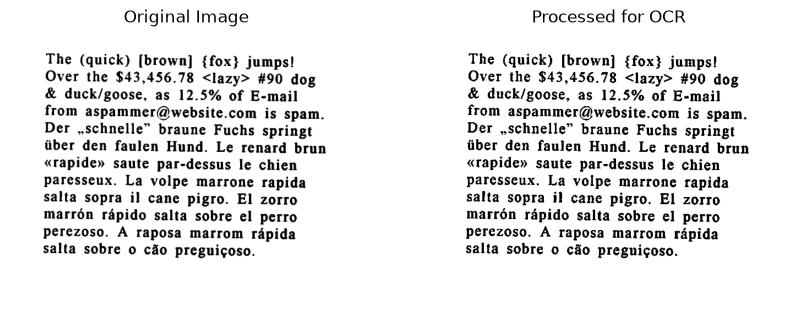

[US LICENSE PLATE / TEXT TEST RESULTS]
----------------------------------------
The (quick) [brown] {fox} jumps!
Over the $43,456.78 <lazy> #90 dog
& duck/goose, as 12.5% of E-mail
from aspammer@website.com is spam.
Der ,,schnelle” braune Fuchs springt
uber den faulen Hund. Le renard brun
«rapide» saute par-dessus le chien
paresseux. La volpe marrone rapida
salta sopra il cane pigro. El zorro
marrén rapido salta sobre el perro
perezoso. A raposa marrom rapida
salta sobre 0 cdo pregnigoso.
----------------------------------------



'The (quick) [brown] {fox} jumps!\nOver the $43,456.78 <lazy> #90 dog\n& duck/goose, as 12.5% of E-mail\nfrom aspammer@website.com is spam.\nDer ,,schnelle” braune Fuchs springt\nuber den faulen Hund. Le renard brun\n«rapide» saute par-dessus le chien\nparesseux. La volpe marrone rapida\nsalta sopra il cane pigro. El zorro\nmarrén rapido salta sobre el perro\nperezoso. A raposa marrom rapida\nsalta sobre 0 cdo pregnigoso.'

In [7]:
# 1. Test US License Plate / Sample Text
plate_sample = "https://raw.githubusercontent.com/tesseract-ocr/tessdoc/main/images/eurotext.png"
analyze_traffic_image(plate_sample, category_name="US License Plate / Text Test")


RUNNING OCR EVALUATION: US License Plate
Error processing US License Plate: cannot identify image file <_io.BytesIO object at 0x77c16164d8f0>

RUNNING OCR EVALUATION: Speed Limit Sign
Error processing Speed Limit Sign: cannot identify image file <_io.BytesIO object at 0x77c1616631f0>

RUNNING OCR EVALUATION: Multi-line Work Zone Sign


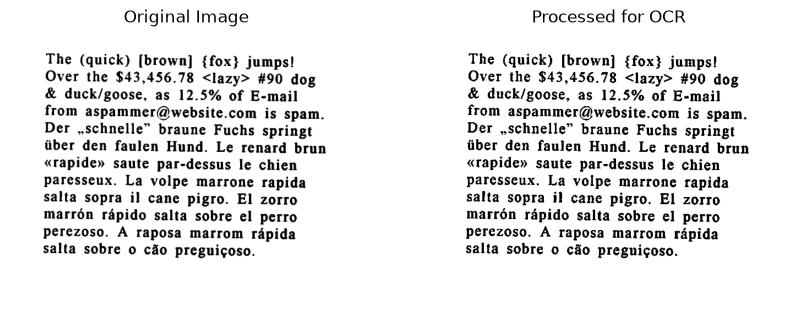

[MULTI-LINE WORK ZONE SIGN RESULTS]
----------------------------------------
The (quick) [brown] {fox} jumps!
Over the $43,456.78 <lazy> #90 dog
& duck/goose, as 12.5% of E-mail
from aspammer@website.com is spam.
Der ,,schnelle” braune Fuchs springt
uber den faulen Hund. Le renard brun
«rapide» saute par-dessus le chien
paresseux. La volpe marrone rapida
salta sopra il cane pigro. El zorro
marrén rapido salta sobre el perro
perezoso. A raposa marrom rapida
salta sobre 0 cdo pregnigoso.
----------------------------------------



In [8]:
# Create a test dictionary of traffic signs and plates
test_cases = {
    "US License Plate": "https://raw.githubusercontent.com/jonkeegan/us-license-plates/main/images/ny-excelsior.jpg",
    "Speed Limit Sign": "https://raw.githubusercontent.com/michaelgallacher/speed-limit-sign-detection/main/images/1_20210204123000_35.jpg",
    "Multi-line Work Zone Sign": "https://raw.githubusercontent.com/tesseract-ocr/tessdoc/main/images/eurotext.png"
}

# Run the pipeline across all test categories
for category, url in test_cases.items():
    print(f"\n========================================")
    print(f"RUNNING OCR EVALUATION: {category}")
    print(f"========================================")
    try:
        analyze_traffic_image(url, category_name=category)
    except Exception as e:
        print(f"Error processing {category}: {e}")